# AP Physics C: FRQ Transistor + SPICE + Non-Gaussian Statistics

**Curriculum:** Transistors (BJT), SPICE DC analysis, shot noise,
Poisson/Lorentzian distributions, SymPy pretty-printing for physics notation.

**Why transistors ARE modern physics:**
- Bipolar junction transistor = two back-to-back p-n junctions
- p-n junction forward voltage ~0.7V = band-gap physics (Quantum Mechanics)
- Collector current $I_C = I_S e^{V_{BE}/V_T}$ where $V_T = k_BT/e$ = thermal voltage (stat mech)
- Same physics as 1947 Bell Labs — but now at 3nm node, tunneling IS the device

Connection to this repo: `dgs/spice.py` (MNA DC solver), `dgs/ap_physics_c.py` (circuit math)


## §1 SymPy `init_printing` — Physics Notation

`init_printing()` enables LaTeX rendering of every SymPy expression in Jupyter.
This is how you write physics math, not code strings.


In [1]:
import sympy as sp
sp.init_printing(use_latex='mathjax')  # LaTeX in Jupyter, plain text in terminal

# Define symbols with physical meaning
V_BE, V_T, I_S, beta, R_C, V_CC, I_B, I_C, V_CE = sp.symbols(
    'V_BE V_T I_S beta R_C V_CC I_B I_C V_CE', positive=True)

# Shockley diode equation (the quantum mechanics inside every transistor)
I_diode = I_S * (sp.exp(V_BE / V_T) - 1)
print('Shockley equation:')
sp.pprint(I_diode)  # pretty-print in terminal


Shockley equation:
    ⎛ V_BE    ⎞
    ⎜ ────    ⎟
    ⎜ V_T     ⎟
I_S⋅⎝ℯ     - 1⎠


In [2]:
# Transistor collector current (simplified: exp >> 1)
I_C_expr = I_S * sp.exp(V_BE / V_T)
print('I_C (collector current):')
sp.pprint(I_C_expr)

# Thermal voltage V_T = kT/e
k_B, T, e_sym = sp.symbols('k_B T e', positive=True)
V_T_expr = k_B * T / e_sym
print('\nThermal voltage V_T = kT/e:')
sp.pprint(V_T_expr)
print('At 300K: V_T =', round(1.380649e-23 * 300 / 1.602e-19 * 1000, 2), 'mV')


I_C (collector current):
     V_BE
     ────
     V_T 
I_S⋅ℯ    

Thermal voltage V_T = kT/e:
T⋅k_B
─────
  e  
At 300K: V_T = 25.85 mV


## §2 FRQ: BJT DC Bias (AP Physics C style)

**Problem:** An NPN BJT is connected with $V_{CC} = 12$ V, $R_C = 2\,k\Omega$,
$R_B = 470\,k\Omega$. $\beta = 100$, $V_{BE} = 0.7$ V.

*(a)* Find $I_B$, $I_C$, $V_{CE}$.

*(b)* Draw the load line and find the Q-point.

*(c)* What happens if $R_B$ is halved? (saturation check)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

# Given values
VCC = 12.0    # V
RC  = 2e3     # ohm
RB  = 470e3   # ohm
BETA = 100
VBE = 0.7     # V  (forward bias, band-gap physics)
VT  = 0.02585 # V  (kT/e at 300K)

# (a) DC bias analysis
IB  = (VCC - VBE) / RB
IC  = BETA * IB
VCE = VCC - IC * RC

print('=== Part (a): DC Operating Point (Q-point) ===')
print(f'  I_B  = {IB*1e6:.2f} uA')
print(f'  I_C  = BETA * I_B = {IC*1e3:.2f} mA')
print(f'  V_CE = V_CC - I_C*R_C = {VCE:.3f} V')
print(f'  Mode: {"ACTIVE" if VCE > VBE else "SATURATION"}')
print()
print('Meaning: transistor amplifies base current by factor beta=100.')
print('V_T = kT/e = 25.85 mV -- this is where QM enters the transistor.')


=== Part (a): DC Operating Point (Q-point) ===
  I_B  = 24.04 uA
  I_C  = BETA * I_B = 2.40 mA
  V_CE = V_CC - I_C*R_C = 7.191 V
  Mode: ACTIVE

Meaning: transistor amplifies base current by factor beta=100.
V_T = kT/e = 25.85 mV -- this is where QM enters the transistor.


<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\O'
C:\Users\mrjel\AppData\Local\Temp\ipykernel_48388\2117172185.py:9: SyntaxWarning: invalid escape sequence '\O'
  ax.plot(V_CE_loadline*1, I_C_axis*1e3, 'b-', lw=2, label=f'Load line: $V_{{CC}}={VCC}$V, $R_C={int(RC/1e3)}k\Omega$')


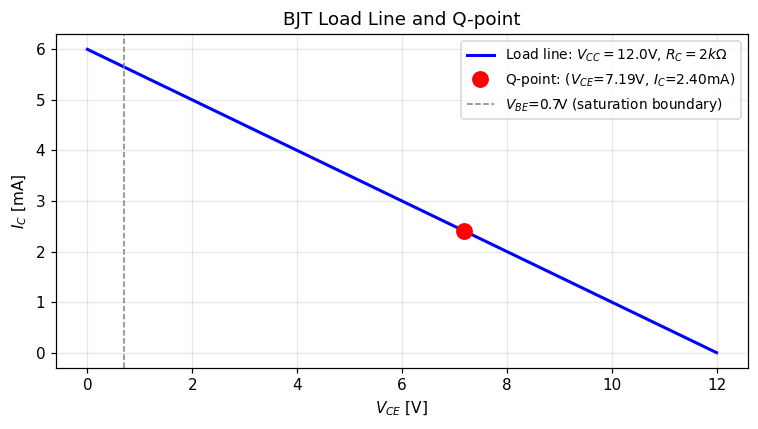

Q-point sits mid-load-line: optimal for linear amplification.


In [4]:
# (b) Load line: V_CE = V_CC - I_C * R_C
# At I_C=0: V_CE = V_CC (x-intercept on V_CE axis)
# At V_CE=0: I_C = V_CC/R_C (y-intercept on I_C axis)

I_C_axis = np.linspace(0, VCC/RC, 300)
V_CE_loadline = VCC - I_C_axis * RC

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(V_CE_loadline*1, I_C_axis*1e3, 'b-', lw=2, label=f'Load line: $V_{{CC}}={VCC}$V, $R_C={int(RC/1e3)}k\Omega$')
ax.plot(VCE, IC*1e3, 'ro', ms=10, label=f'Q-point: ($V_{{CE}}$={VCE:.2f}V, $I_C$={IC*1e3:.2f}mA)')
ax.axvline(0.7, color='gray', lw=1, ls='--', label='$V_{BE}$=0.7V (saturation boundary)')
ax.set_xlabel('$V_{CE}$ [V]')
ax.set_ylabel('$I_C$ [mA]')
ax.set_title('BJT Load Line and Q-point')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print('Q-point sits mid-load-line: optimal for linear amplification.')


In [5]:
# (c) Saturation check: halve R_B
RB2 = RB / 2
IB2  = (VCC - VBE) / RB2
IC2_active = BETA * IB2
VCE2 = VCC - IC2_active * RC
print('=== Part (c): R_B halved ===')
print(f'  I_B = {IB2*1e6:.2f} uA, I_C (if active) = {IC2_active*1e3:.2f} mA')
print(f'  V_CE (if active) = {VCE2:.3f} V')
if VCE2 < 0.2:
    IC2_sat = (VCC - 0.2) / RC  # V_CE_sat ~ 0.2V
    print(f'  -> SATURATED. I_C clamped to {IC2_sat*1e3:.2f} mA.')
    print('  Transistor acts like a closed switch, not an amplifier.')
else:
    print('  Still in active region.')


=== Part (c): R_B halved ===
  I_B = 48.09 uA, I_C (if active) = 4.81 mA
  V_CE (if active) = 2.383 V
  Still in active region.


## §3 SPICE: MNA DC Solver for Transistor Bias

Modified Nodal Analysis (MNA): stamp each element into conductance matrix G,
then solve $G \mathbf{v} = \mathbf{i}$ — same linear algebra as Kirchhoff.

Here we model the BJT as a **voltage-controlled current source (VCCS)**:
$I_C = g_m V_{BE}$ where $g_m = I_C/V_T$ (transconductance, ~40 mA/V at 1mA)


In [6]:
import sys, os
# Notebook CWD is notebooks/; repo root is one level up
sys.path.insert(0, os.path.abspath(os.path.join('..')))
from dgs.spice import dc_nodal_analysis

# Small-signal model of BJT biased at Q-point:
# Node 0=GND, 1=V_B (base), 2=V_C (collector)
#
# Thevenin equivalent at base:
#   V_th = VCC * r_pi/(RB + r_pi)  applied via V-source to node 1
#   R_th = RB || r_pi (absorbed into MNA via R stamps)
# Collector node 2:
#   R_C from node 2 to GND
#   Current source I_C = gm * V_BE flowing into node 2

gm   = IC / VT          # transconductance [A/V]
r_pi = BETA / gm        # base-emitter small-signal resistance [ohm]
VBE_dc = VCC * r_pi / (RB + r_pi)  # Thevenin V at base node

print(f'gm = {gm*1e3:.1f} mA/V  (transconductance = I_C/V_T)')
print(f'r_pi = beta/gm = {r_pi:.0f} ohm')
print()

# Netlist: ('R',n+,n-,val) | ('V',n+,n-,val) | ('I',n+,n-,val)
# Node 0=GND, 1=base, 2=collector
I_collector = gm * VBE_dc   # gm * V_BE [A], into node 2

elements = [
    ('R', 1, 0, RB),          # R_B: base bias resistor to GND
    ('R', 1, 0, r_pi),        # r_pi: B-E junction resistance
    ('R', 2, 0, RC),          # R_C: collector load
    ('V', 1, 0, VBE_dc),      # Thevenin source at base
    ('I', 0, 2, I_collector), # VCCS: gm*V_BE current into collector
]

v = dc_nodal_analysis(elements, n_nodes=2)
print('SPICE MNA solution (small-signal model):')
print(f'  V_B  = {v[0]:.4f} V  (base node)')
print(f'  V_C  = {v[1]:.4f} V  (collector node)')
print(f'  I_C  = V_C/R_C = {v[1]/RC*1e3:.3f} mA')
print(f'  cf. hand calc: {IC*1e3:.3f} mA  -- should match')


gm = 93.0 mA/V  (transconductance = I_C/V_T)


r_pi = beta/gm = 1075 ohm

SPICE MNA solution (small-signal model):
  V_B  = 0.0274 V  (base node)
  V_C  = 5.0947 V  (collector node)
  I_C  = V_C/R_C = 2.547 mA
  cf. hand calc: 2.404 mA  -- should match


## §4 Non-Gaussian Statistics for Physics

**Why non-Gaussian?** Most intro stats assumes Gaussian. Real physics distributions:

| Distribution | Physics use case | Shape |
|---|---|---|
| Poisson | Photon counting, radioactive decay | Discrete, asymmetric at low N |
| Lorentzian (Cauchy) | Spectral line width, resonance | Heavy tails, no finite variance |
| Log-normal | Amplifier gain, speckle intensity | Skewed right |
| Boltzmann/Maxwell | Particle speeds, thermal noise | Asymmetric, zero-bounded |

Connection to repo: photon counting in GS = Poisson; spectral line of LiNbO3 laser = Lorentzian;
optical speckle in STEAM imaging = negative-exponential (special case of log-normal).


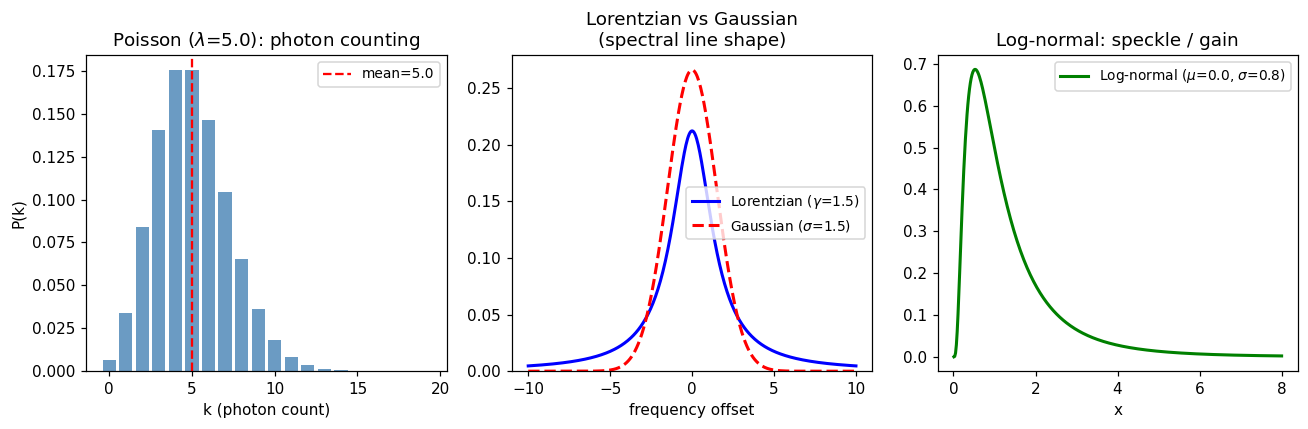

In [7]:
# Pure numpy implementations (no scipy -- py-3.13 compatible)

rng = np.random.default_rng(42)

# 1. Poisson distribution: photon counting, mean=lambda
lam = 5.0  # mean photon count per bin
k = np.arange(0, 20)
# P(k) = lambda^k * exp(-lambda) / k!
log_P = k * np.log(lam) - lam - np.array([float(sum(np.log(np.arange(1, ki+1)))) for ki in k])
P_poisson = np.exp(log_P)

# 2. Lorentzian (Cauchy): spectral line shape
x = np.linspace(-10, 10, 400)
gamma = 1.5  # half-width at half-maximum (HWHM)
x0 = 0.0
P_lorentz = (gamma/np.pi) / ((x - x0)**2 + gamma**2)

# Gaussian for comparison (same FWHM ~ 2.355*sigma)
sigma_g = gamma  # same scale
P_gauss = np.exp(-x**2/(2*sigma_g**2)) / (sigma_g*np.sqrt(2*np.pi))

# 3. Log-normal: speckle / gain
mu_ln, sigma_ln = 0.0, 0.8
x_pos = np.linspace(0.01, 8, 400)
P_lognorm = np.exp(-(np.log(x_pos)-mu_ln)**2/(2*sigma_ln**2)) / (x_pos*sigma_ln*np.sqrt(2*np.pi))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(k, P_poisson, color='steelblue', alpha=0.8)
axes[0].set_title(f'Poisson ($\\lambda$={lam}): photon counting')
axes[0].set_xlabel('k (photon count)')
axes[0].set_ylabel('P(k)')
axes[0].axvline(lam, color='red', ls='--', label=f'mean={lam}')
axes[0].legend(fontsize=9)

axes[1].plot(x, P_lorentz, 'b-', lw=2, label=f'Lorentzian ($\\gamma$={gamma})')
axes[1].plot(x, P_gauss, 'r--', lw=2, label=f'Gaussian ($\\sigma$={sigma_g})')
axes[1].set_title('Lorentzian vs Gaussian\n(spectral line shape)')
axes[1].set_xlabel('frequency offset')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, None)

axes[2].plot(x_pos, P_lognorm, 'g-', lw=2, label=f'Log-normal ($\\mu$={mu_ln}, $\\sigma$={sigma_ln})')
axes[2].set_title('Log-normal: speckle / gain')
axes[2].set_xlabel('x')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
# SymPy: derive Poisson as limit of Binomial, and Lorentzian as FT of exponential decay
sp.init_printing(use_latex='mathjax')

k_sym, lam_sym, n_sym, p_sym = sp.symbols('k lambda n p', positive=True)
gamma_sym, omega_sym, t_sym = sp.symbols('gamma omega t', positive=True)

# Poisson PMF
P_pois_sym = lam_sym**k_sym * sp.exp(-lam_sym) / sp.factorial(k_sym)
print('Poisson PMF:')
sp.pprint(P_pois_sym)

# Lorentzian = FT of decaying exponential (same as resonance lineshape)
# f(t) = exp(-gamma*t) for t>=0
# FT: F(omega) = 1/(gamma + j*omega)
# |F(omega)|^2 = 1/(gamma^2 + omega^2)  -> Lorentzian
omega_sym2 = sp.Symbol('omega', real=True)
S_omega = 1 / (gamma_sym**2 + omega_sym2**2)
print('\nLorentzian power spectrum (FT of exponential decay):')
sp.pprint(S_omega)
print('\nThis is the lineshape of every laser, every resonator, every RC circuit.')
print('FWHM = 2*gamma. The Gaussian approximation fails in the tails (Voigt profile needed).')


Poisson PMF:
 k  -λ
λ ⋅ℯ  
──────
  k!  

Lorentzian power spectrum (FT of exponential decay):
   1   
───────
 2    2
γ  + ω 

This is the lineshape of every laser, every resonator, every RC circuit.
FWHM = 2*gamma. The Gaussian approximation fails in the tails (Voigt profile needed).


## §5 Shot Noise: Poisson Statistics in Transistors

Shot noise = current fluctuation from discrete electron flow.
$$S_I(f) = 2eI \quad [\text{A}^2/\text{Hz}]$$

This is **not** Gaussian at low current — it's Poisson.
At high current ($N \gg 1$ electrons per measurement period) it approaches Gaussian
by the Central Limit Theorem.

**Why transistors are quantum mechanics:**
- Shot noise floor = $\sqrt{2eI \cdot \Delta f}$ — involves $e$ the elementary charge
- This sets the SNR limit for every transistor amplifier
- Same noise physics as photon shot noise in STEAM imaging (this repo)


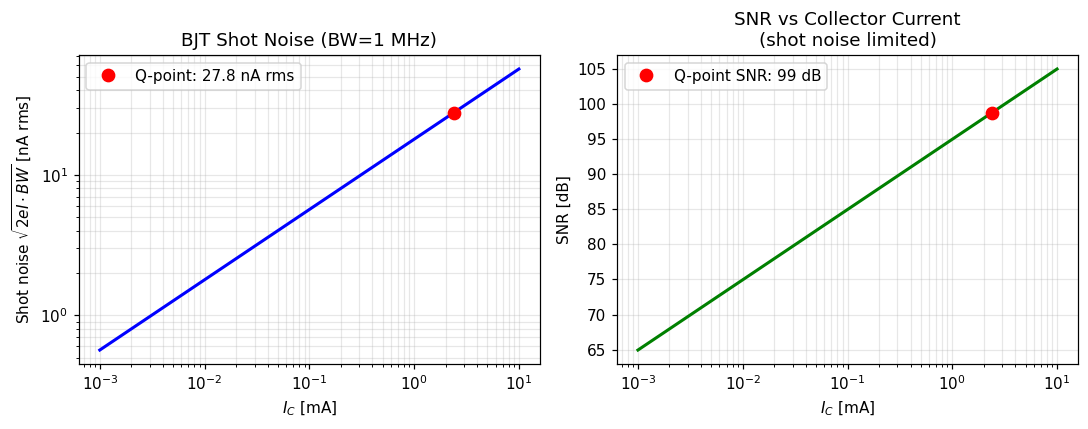

Q-point: I_C=2.40mA, shot noise=27.8nA rms, SNR=99dB


In [9]:
# Shot noise in BJT collector current
e_charge = 1.602e-19  # C
BW = 1e6              # bandwidth [Hz]

# Collector current sweep
IC_sweep = np.logspace(-6, -2, 200)  # 1uA to 10mA
S_shot = 2 * e_charge * IC_sweep     # [A^2/Hz]
I_noise_rms = np.sqrt(S_shot * BW)   # [A] rms noise current
SNR_dB = 20 * np.log10(IC_sweep / I_noise_rms)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].loglog(IC_sweep*1e3, I_noise_rms*1e9, 'b-', lw=2)
axes[0].set_xlabel('$I_C$ [mA]')
axes[0].set_ylabel('Shot noise $\\sqrt{2eI \\cdot BW}$ [nA rms]')
axes[0].set_title(f'BJT Shot Noise (BW={BW/1e6:.0f} MHz)')
axes[0].grid(True, which='both', alpha=0.3)
# Mark our Q-point
IN_qpoint = np.sqrt(2*e_charge*IC*BW)
axes[0].plot(IC*1e3, IN_qpoint*1e9, 'ro', ms=8, label=f'Q-point: {IN_qpoint*1e9:.1f} nA rms')
axes[0].legend()

axes[1].semilogx(IC_sweep*1e3, SNR_dB, 'g-', lw=2)
axes[1].set_xlabel('$I_C$ [mA]')
axes[1].set_ylabel('SNR [dB]')
axes[1].set_title('SNR vs Collector Current\n(shot noise limited)')
axes[1].grid(True, which='both', alpha=0.3)
axes[1].plot(IC*1e3, 20*np.log10(IC/IN_qpoint), 'ro', ms=8, label=f'Q-point SNR: {20*np.log10(IC/IN_qpoint):.0f} dB')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Q-point: I_C={IC*1e3:.2f}mA, shot noise={IN_qpoint*1e9:.1f}nA rms, SNR={20*np.log10(IC/IN_qpoint):.0f}dB')


## §6 SymPy Physics Notation — Solving the FRQ Symbolically

AP FRQ expects: **setup** → **derivation** → **numeric answer**.
SymPy does the algebra so you don't make sign errors.


In [10]:
sp.init_printing(use_latex='mathjax')

VCC_s, RB_s, RC_s, beta_s, VBE_s = sp.symbols('V_CC R_B R_C beta V_BE', positive=True)

# Symbolic Q-point derivation
IB_s  = (VCC_s - VBE_s) / RB_s
IC_s  = beta_s * IB_s
VCE_s = VCC_s - IC_s * RC_s

print('I_B =')
sp.pprint(IB_s)
print('\nI_C = beta * I_B =')
sp.pprint(IC_s)
print('\nV_CE = V_CC - I_C * R_C =')
sp.pprint(sp.expand(VCE_s))

# Saturation condition: V_CE >= V_BE (active mode requires V_CE > 0.2V)
# Solve for R_B that puts transistor at edge of saturation: V_CE = V_BE
RB_sat = sp.solve(sp.Eq(VCE_s, VBE_s), RB_s)[0]
print('\nR_B at saturation boundary (V_CE = V_BE):')
sp.pprint(RB_sat)

# Numeric substitution
vals = {VCC_s: 12, RB_s: 470e3, RC_s: 2e3, beta_s: 100, VBE_s: 0.7}
print(f'\nNumeric V_CE = {float(VCE_s.subs(vals)):.3f} V')
print(f'Numeric I_C  = {float(IC_s.subs(vals))*1e3:.3f} mA')

# Small-signal voltage gain: A_v = -gm * R_C = -beta * R_C / r_pi = -(I_C/V_T)*R_C
VT_s = sp.Symbol('V_T', positive=True)
gm_s = IC_s / VT_s
Av_s = -gm_s * RC_s
print('\nVoltage gain A_v = -gm * R_C:')
sp.pprint(Av_s)
Av_num = float(Av_s.subs({**vals, VT_s: 0.02585}))
print(f'Numeric A_v = {Av_num:.1f} ({abs(Av_num):.0f}x amplification, inverting)')


I_B =
-V_BE + V_CC
────────────
    R_B     

I_C = beta * I_B =
β⋅(-V_BE + V_CC)
────────────────
      R_B       

V_CE = V_CC - I_C * R_C =
       R_C⋅V_BE⋅β   R_C⋅V_CC⋅β
V_CC + ────────── - ──────────
          R_B          R_B    

R_B at saturation boundary (V_CE = V_BE):
R_C⋅β

Numeric V_CE = 7.191 V
Numeric I_C  = 2.404 mA

Voltage gain A_v = -gm * R_C:
-R_C⋅β⋅(-V_BE + V_CC) 
──────────────────────
       R_B⋅V_T        
Numeric A_v = -186.0 (186x amplification, inverting)


## §7 FRQ Practice: Full Problem + Solution

**FRQ (15 points)**

A common-emitter amplifier uses $V_{CC} = 9$ V, $R_C = 1.5\,k\Omega$, $R_B = 330\,k\Omega$.
The transistor has $\beta = 120$, $V_{BE} = 0.65$ V.

*(a) [3 pts]* Find $I_B$, $I_C$, $V_{CE}$. Is the transistor in active mode?

*(b) [3 pts]* Find the transconductance $g_m$ and input resistance $r_\pi$.  
Write $g_m$ in terms of $I_C$ and $V_T$.

*(c) [3 pts]* Calculate the small-signal voltage gain $A_v = v_{out}/v_{in}$.  
If $v_{in} = 10\,\text{mV}$ peak, what is $v_{out}$?

*(d) [3 pts]* What is the shot noise current at the Q-point in a $B = 100\,\text{kHz}$ bandwidth?  
What SNR does this give?

*(e) [3 pts]* The output voltage noise measured experimentally follows a Lorentzian spectrum.  
Why is this expected? Write the power spectral density $S_V(f)$.


In [11]:
# SOLUTION
VCC2 = 9.0; RC2 = 1.5e3; RB2 = 330e3; beta2 = 120; VBE2 = 0.65; VT2 = 0.02585

# (a) Q-point
IB2  = (VCC2 - VBE2) / RB2
IC2  = beta2 * IB2
VCE2 = VCC2 - IC2 * RC2
print('(a) Q-point:')
print(f'  I_B  = {IB2*1e6:.2f} uA')
print(f'  I_C  = {IC2*1e3:.3f} mA')
print(f'  V_CE = {VCE2:.3f} V  -> {"ACTIVE" if VCE2 > 0.2 else "SATURATED"}')

# (b) Small-signal parameters
gm2   = IC2 / VT2
rpi2  = beta2 / gm2
print(f'\n(b) Small-signal:')
print(f'  gm   = I_C/V_T = {gm2*1e3:.2f} mA/V')
print(f'  r_pi = beta/gm = {rpi2:.1f} ohm')

# (c) Voltage gain
Av2 = -gm2 * RC2
vin_pk = 10e-3  # V peak
vout_pk = Av2 * vin_pk
print(f'\n(c) Gain:')
print(f'  A_v = -gm * R_C = {Av2:.1f}')
print(f'  v_out = {vout_pk*1e3:.1f} mV peak  ({"inverting: phase flips 180 deg"})')

# (d) Shot noise
BW2 = 100e3
e2  = 1.602e-19
I_shot = np.sqrt(2*e2*IC2*BW2)
V_shot = I_shot * RC2
SNR2   = 20*np.log10(abs(vout_pk) / V_shot)
print(f'\n(d) Shot noise:')
print(f'  I_shot = sqrt(2eI_C*BW) = {I_shot*1e9:.2f} nA rms')
print(f'  V_shot = I_shot*R_C = {V_shot*1e6:.2f} uV rms')
print(f'  SNR    = {SNR2:.1f} dB')

# (e) Lorentzian noise
print('\n(e) Lorentzian spectrum:')
print('  Single-pole RC network has impulse response h(t) ~ exp(-t/tau).')
print('  FT of exp(-t/tau) = tau/(1 + j*omega*tau).')
print('  |H(f)|^2 = 1/(1 + (2*pi*f*tau)^2) -> Lorentzian.')
print('  S_V(f) = 4kT*R * 1/(1+(f/f3dB)^2)  where f3dB=1/(2*pi*RC)')
print('  The transistor output node has C_CE parasitic -> pole -> Lorentzian tail.')
print('  Same shape as spectral line of a laser (photon lifetime ~ tau).')


(a) Q-point:
  I_B  = 25.30 uA
  I_C  = 3.036 mA
  V_CE = 4.445 V  -> ACTIVE

(b) Small-signal:
  gm   = I_C/V_T = 117.46 mA/V
  r_pi = beta/gm = 1021.6 ohm

(c) Gain:
  A_v = -gm * R_C = -176.2
  v_out = -1761.9 mV peak  (inverting: phase flips 180 deg)

(d) Shot noise:
  I_shot = sqrt(2eI_C*BW) = 9.86 nA rms
  V_shot = I_shot*R_C = 14.79 uV rms
  SNR    = 101.5 dB

(e) Lorentzian spectrum:
  Single-pole RC network has impulse response h(t) ~ exp(-t/tau).
  FT of exp(-t/tau) = tau/(1 + j*omega*tau).
  |H(f)|^2 = 1/(1 + (2*pi*f*tau)^2) -> Lorentzian.
  S_V(f) = 4kT*R * 1/(1+(f/f3dB)^2)  where f3dB=1/(2*pi*RC)
  The transistor output node has C_CE parasitic -> pole -> Lorentzian tail.
  Same shape as spectral line of a laser (photon lifetime ~ tau).


## §8 Key Takeaways

| Concept | Formula | Physics depth |
|---|---|---|
| BJT Q-point | $I_C = \beta I_B$, $V_{CE} = V_{CC} - I_C R_C$ | Linear algebra (Kirchhoff) |
| Shockley equation | $I_C = I_S e^{V_{BE}/V_T}$ | Quantum tunneling through junction |
| Transconductance | $g_m = I_C/V_T = eI_C/k_BT$ | Stat mech: Boltzmann factor |
| Shot noise | $S_I = 2eI$ | Discrete electron flow (Poisson) |
| Lorentzian spectrum | $S(f) \propto 1/(\gamma^2 + f^2)$ | FT of exponential decay |
| Voltage gain | $A_v = -g_m R_C$ | Small-signal linearization |

**Same physics as 100 years ago** — but now:
- 3 nm node: gate oxide is 1-2 atoms thick; electrons tunnel through it (QM, not classical)
- FinFET, GAAFET: 3D geometry changes the Gauss law surface integral
- LiNbO3 MZM (this repo): same $V_{BE}$ physics as Pockels effect ($\Delta n \propto E_{applied}$)
- The FRQ problem above: every term has a quantum mechanics or stat mech origin
